# Exam 1
## Bibek Thapa 



## Question 1 (World Cup Players Data Visualization)  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display, Image
import seaborn as sns
from matplotlib.patches import Patch

In [2]:
# Q1 Load the 2022 World Cup Players dataset into a DataFrame
url = "https://raw.githubusercontent.com/nurfnick/Data_Sets_For_Stats/refs/heads/master/CuratedDataSets/2022WorldCupPlayers.csv"
df = pd.read_csv(url)

# Quick preview to confirm it loaded correctly
df.head()

,player,position,nationality,age,club,birth_year,games,games_starts,minutes,minutes_90s,...,goals_assists_pens_per90,xg,npxg,xg_assist,npxg_xg_assist,xg_per90,xg_assist_per90,xg_xg_assist_per90,npxg_per90,npxg_xg_assist_per90
0,Aaron Mooy,MF,Australia,32-094,Celtic,1990,4,4,360,4.0,...,0.0,0.0,0.0,0.1,0.1,0.01,0.02,0.03,0.01,0.03
1,Aaron Ramsey,MF,Wales,31-357,Nice,1990,3,3,266,3.0,...,0.0,0.0,0.0,0.0,0.1,0.01,0.01,0.02,0.01,0.02
2,Abdelhamid Sabiri,MF,Morocco,26-020,Sampdoria,1996,5,2,181,2.0,...,0.5,0.1,0.1,0.9,1.0,0.08,0.53,0.60,0.08,0.60
3,Abdelkarim Hassan,DF,Qatar,29-112,Al Sadd SC,1993,3,3,270,3.0,...,0.0,0.3,0.3,0.0,0.3,0.10,0.01,0.11,0.10,0.11
4,Abderrazak Hamdallah,FW,Morocco,32-001,Al-Ittihad,1990,4,0,68,0.8,...,0.0,0.4,0.4,0.0,0.4,0.52,0.00,0.52,0.52,0.52


### Q1(a) Store the data as a pandas dataframe. Find your favorite `club` or `nationality` (that is present in thedata!), include a picture that represents them and include it in your notebook. (If no favorite, just pick one!)


Does 'Argentina' exist in the dataset? -> True

--- Favorite team selection ---
Chosen favorite nationality: Argentina
Number of players from favorite nationality: 24

--- Sample of players from my favorite nationality ---


,player,nationality,is_favorite
30,Alexis Mac Allister,Argentina,Favorite
133,Cristian Romero,Argentina,Favorite
184,Emiliano Martínez,Argentina,Favorite
187,Enzo Fernández,Argentina,Favorite
194,Exequiel Palacios,Argentina,Favorite
220,Germán Pezzella,Argentina,Favorite
227,Gonzalo Montiel,Argentina,Favorite
233,Guido Rodríguez,Argentina,Favorite
326,Juan Foyth,Argentina,Favorite
330,Julián Álvarez,Argentina,Favorite



--- Count of Favorite vs Other players in the dataset ---


is_favorite
Other       656
Favorite     24
Name: count, dtype: int64


--- Flag image representing my favorite nationality ---


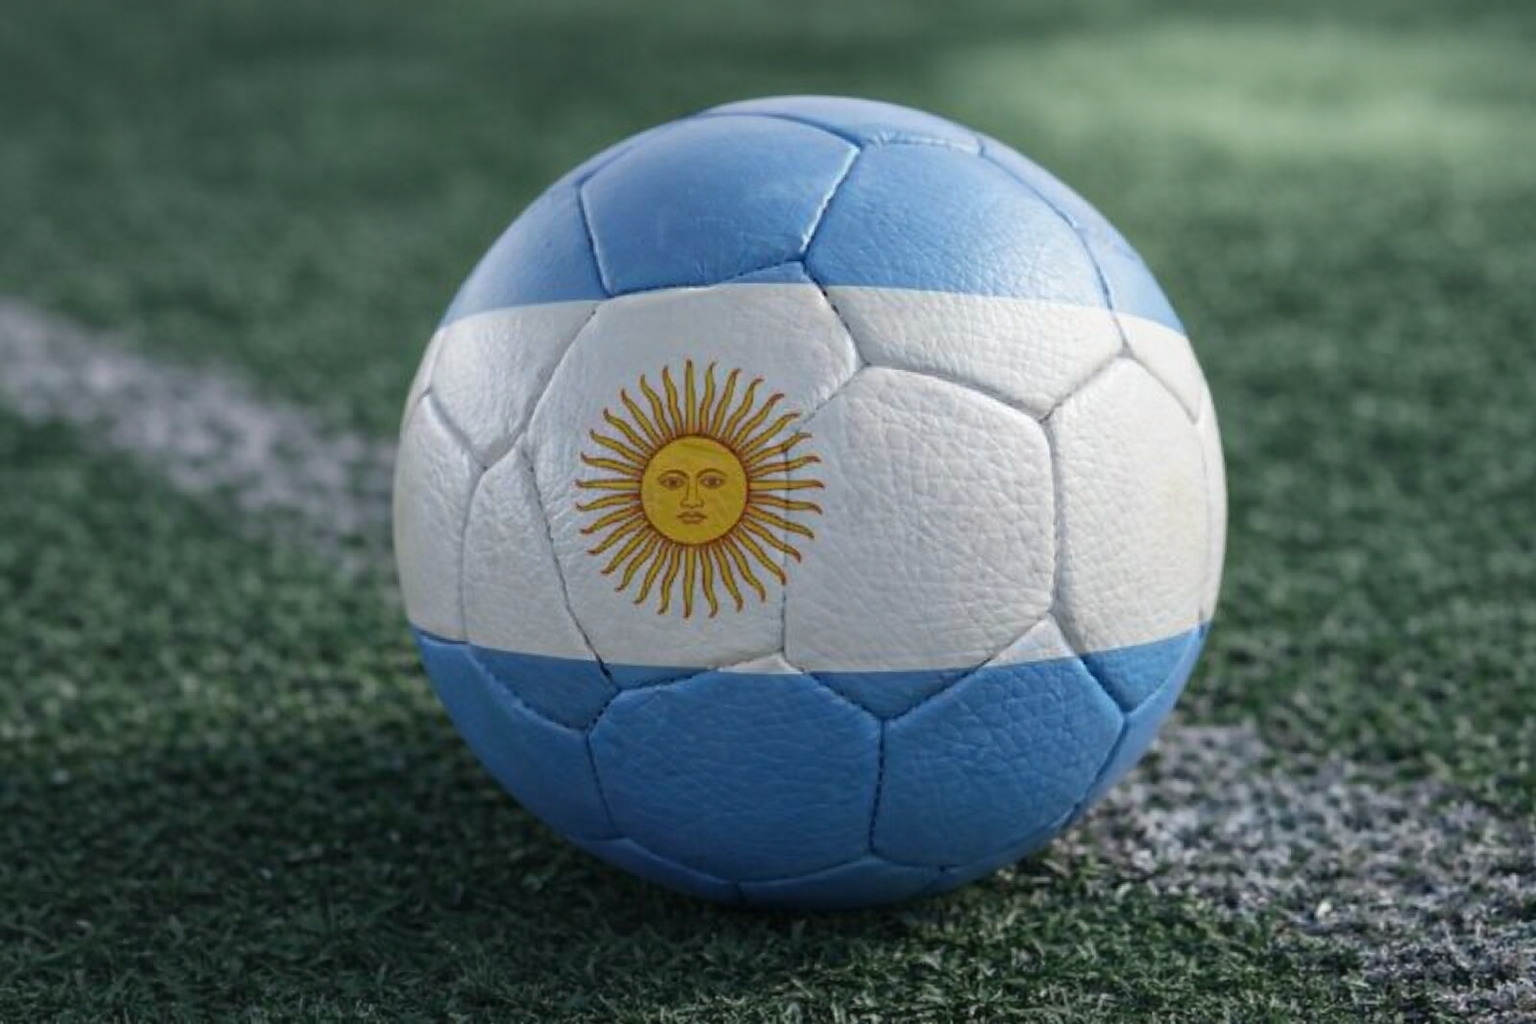

In [3]:
favorite_team = "Argentina"

nat_clean = df["nationality"].astype(str).str.strip().str.lower()
fav_clean = favorite_team.strip().lower()

team_exists = (nat_clean == fav_clean).any()
print(f"Does '{favorite_team}' exist in the dataset? ->", team_exists)

if not team_exists:
    favorite_team = df["nationality"].value_counts().index[0]
    fav_clean = favorite_team.strip().lower()
    print("Fallback favorite team:", favorite_team)

print("\n--- Favorite team selection ---")
print("Chosen favorite nationality:", favorite_team)
print("Number of players from favorite nationality:", (nat_clean == fav_clean).sum())

df["is_favorite"] = np.where(nat_clean == fav_clean, "Favorite", "Other")

print("\n--- Sample of players from my favorite nationality ---")
display(df[nat_clean == fav_clean][["player", "nationality", "is_favorite"]].head(10))

print("\n--- Count of Favorite vs Other players in the dataset ---")
display(df["is_favorite"].value_counts())

print("\n--- Flag image representing my favorite nationality ---")
display(Image(filename="images/Argentina.png", width=200, height=200))

For the question, I picked **Argentina** as my favorite nationality (mainly because I’m a big Messi fan).  
To make sure my selection matches the data correctly, I first cleaned the `team` column by removing extra spaces and converting everything to lowercase. Then I double-checked that **Argentina** actually exists in the dataset and printed how many players belong to it.  

After that, I created a simple helper column called `is_favorite` that tags Argentina players as **Favorite** and everyone else as **Other** this will let me highlight Argentina easily in later graphs.  
At the end, I showed a small sample of Argentina players, the overall counts of Favorite vs Other, and displayed the Argentina flag as the picture representing my choice.



### Q1(b) Create a histogram of the `Goals`

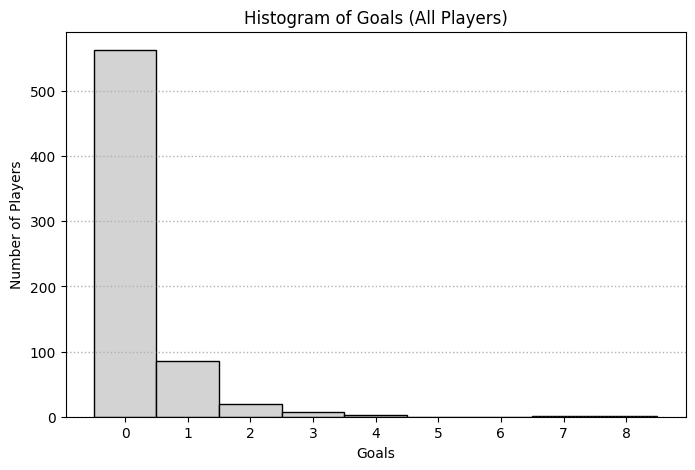

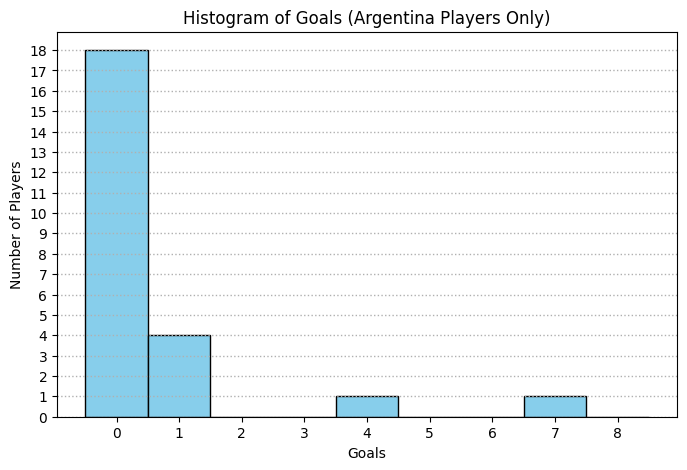

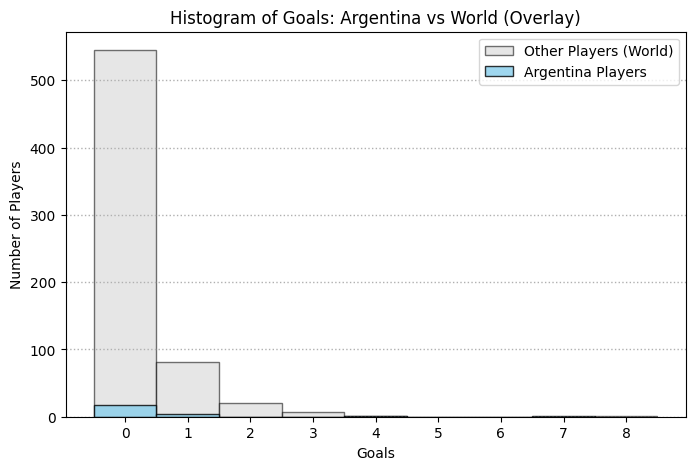

In [4]:
max_goal = int(df["goals"].max())
bins_int = np.arange(-0.5, max_goal + 1.5, 1)

# 1) World (all players)
goals_all = df["goals"].dropna()

plt.figure(figsize=(8,5))
plt.hist(goals_all, bins=bins_int, edgecolor="black", color="lightgray")
plt.title("Histogram of Goals (All Players)")
plt.xlabel("Goals")
plt.ylabel("Number of Players")
plt.xticks(range(0, max_goal + 1))
plt.grid(axis="y", linestyle=":", linewidth=1)
plt.show()

# 2) Favorite team only (Argentina)
goals_fav = df[df["is_favorite"] == "Favorite"]["goals"].dropna()

plt.figure(figsize=(8,5))
plt.hist(goals_fav, bins=bins_int, edgecolor="black", color="skyblue")
plt.title("Histogram of Goals (Argentina Players Only)")
plt.xlabel("Goals")
plt.ylabel("Number of Players")
plt.xticks(range(0, max_goal + 1))
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(1))
plt.grid(axis="y", linestyle=":", linewidth=1)
plt.show()

# 3) Overlay comparison (Argentina vs Others)
goals_other = df[df["is_favorite"] == "Other"]["goals"].dropna()

plt.figure(figsize=(8,5))
plt.hist(goals_other, bins=bins_int, alpha=0.55, label="Other Players (World)", edgecolor="black", color="lightgray")
plt.hist(goals_fav, bins=bins_int, alpha=0.80, label="Argentina Players", edgecolor="black", color="skyblue")
plt.title("Histogram of Goals: Argentina vs World (Overlay)")
plt.xlabel("Goals")
plt.ylabel("Number of Players")
plt.xticks(range(0, max_goal + 1))
plt.grid(axis="y", linestyle=":", linewidth=1)
plt.legend()
plt.show()


In this section, I made three histograms to understand how goals are spread out across the tournament. First, I plotted the goals for **all players** to get the big-picture view of scoring. Then I zoomed in and made the same histogram for **Argentina only** (since that’s my favorite team), so I could see how Argentina’s goal totals look on their own. Finally, I overlaid Argentina on top of the rest of the world to compare them side-by-side.

I also changed the binning so the bars line up with whole numbers (0 goals, 1 goal, 2 goals, etc.) because goals are naturally counted as integers. The dotted horizontal lines are just there to make the player counts easier to read across the chart.
```


### Q1(c) Create a histogram of the `Goals` and `Assists` on the same axis.

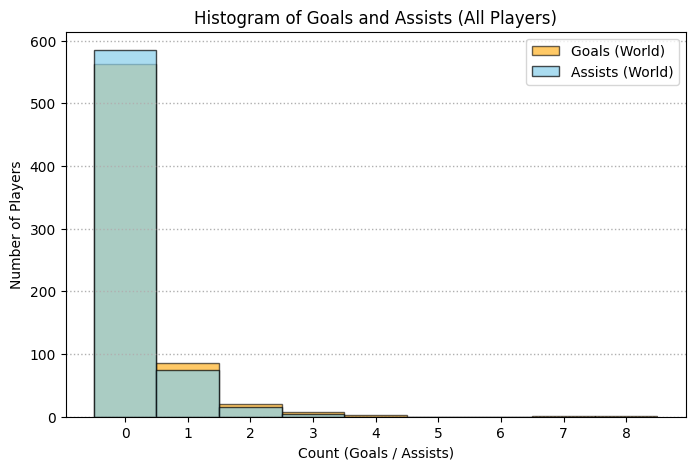

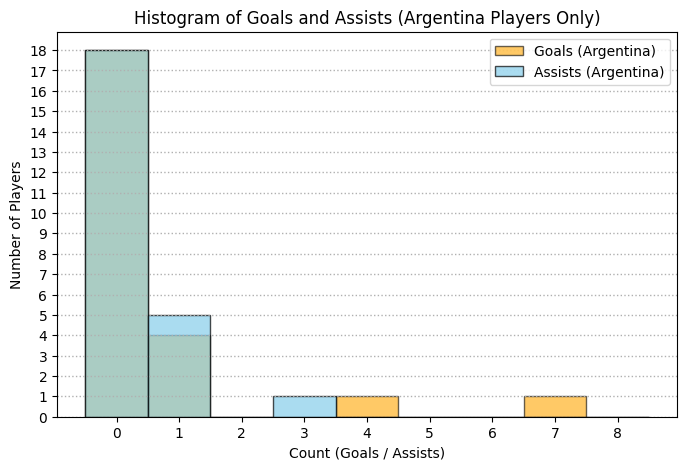

In [5]:
goals_all = df["goals"].dropna()
assists_all = df["assists"].dropna()

goals_fav = df[df["is_favorite"] == "Favorite"]["goals"].dropna()
assists_fav = df[df["is_favorite"] == "Favorite"]["assists"].dropna()

max_val = int(max(goals_all.max(), assists_all.max()))
bins_int = np.arange(-0.5, max_val + 1.5, 1)

# 1) World (all players)
plt.figure(figsize=(8,5))
plt.hist(goals_all, bins=bins_int, alpha=0.60, edgecolor="black", color="orange", label="Goals (World)")
plt.hist(assists_all, bins=bins_int, alpha=0.70, edgecolor="black", color="skyblue", label="Assists (World)")
plt.title("Histogram of Goals and Assists (All Players)")
plt.xlabel("Count (Goals / Assists)")
plt.ylabel("Number of Players")
plt.xticks(range(0, max_val + 1))
plt.grid(axis="y", linestyle=":", linewidth=1)
plt.legend()
plt.show()

# 2) Argentina only
plt.figure(figsize=(8,5))
plt.hist(goals_fav, bins=bins_int, alpha=0.60, edgecolor="black", color="orange", label="Goals (Argentina)")
plt.hist(assists_fav, bins=bins_int, alpha=0.70, edgecolor="black", color="skyblue", label="Assists (Argentina)")
plt.title("Histogram of Goals and Assists (Argentina Players Only)")
plt.xlabel("Count (Goals / Assists)")
plt.ylabel("Number of Players")
plt.xticks(range(0, max_val + 1))
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(1))
plt.grid(axis="y", linestyle=":", linewidth=1)
plt.legend()
plt.show()

In these histograms, I plotted **Goals** and **Assists** on the same axis so I can compare their distributions directly. Because both histograms use transparency (`alpha`) and the bars overlap in many bins (especially at 0 and 1), the colors blend together so the orange (goals) and blue (assists) visually mix into a greenish shade where they sit on top of each other.

That overlap is actually useful: it shows that for Argentina (and for the world), most players are concentrated at **0–1** for both goals and assists, meaning only a few players contribute multiple goals or assists, while the majority have low counts.



### Q1(d) Create a boxplot of `Yel` (yellow cards) by nationality.

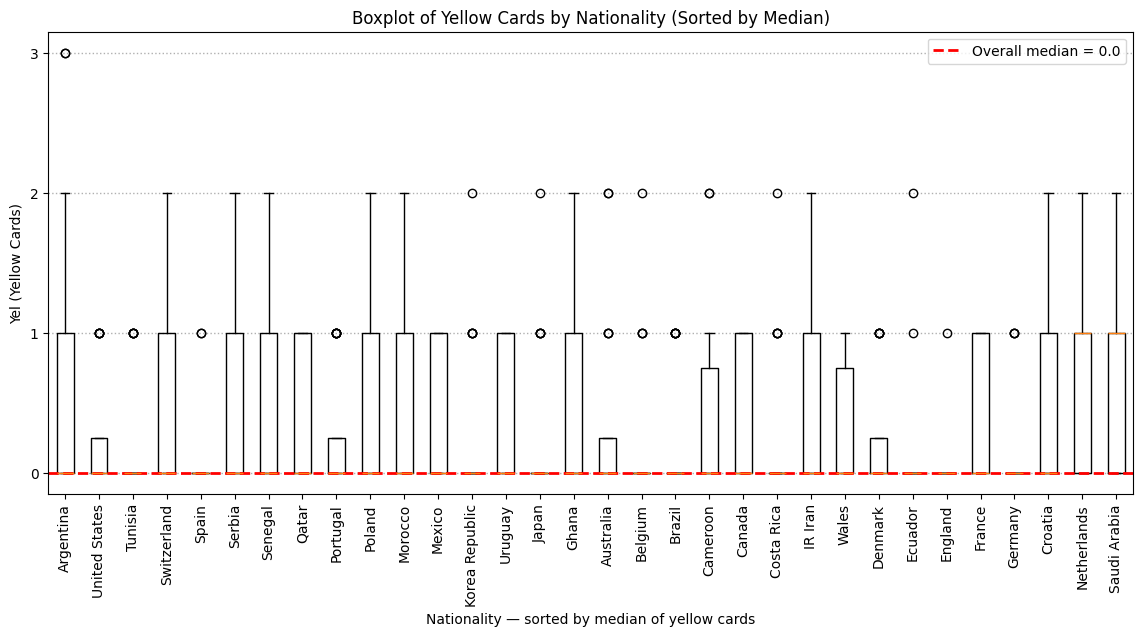

In [6]:
team_medians = df.groupby("nationality")["Yel"].median().sort_values()
teams_sorted = team_medians.index.tolist()
data_sorted = [df[df["nationality"] == t]["Yel"].dropna() for t in teams_sorted]

overall_median = df["Yel"].median()

plt.figure(figsize=(14,6))
plt.boxplot(data_sorted, tick_labels=teams_sorted, showfliers=True)

plt.title("Boxplot of Yellow Cards by Nationality (Sorted by Median)")
plt.xlabel("Nationality — sorted by median of yellow cards")
plt.ylabel("Yel (Yellow Cards)")

plt.axhline(overall_median, linestyle="--", linewidth=2, color="red",
            label=f"Overall median = {overall_median}")

plt.xticks(rotation=90)
plt.grid(axis="y", linestyle=":", linewidth=1)
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(1))
plt.legend()
plt.show()

#### Here I’m making the basic boxplot the question asks for: yellow cards (`cards_yellow`, shown as Yel) grouped by nationality (`team`). This gives a quick summary of how yellow cards are distributed across teams.

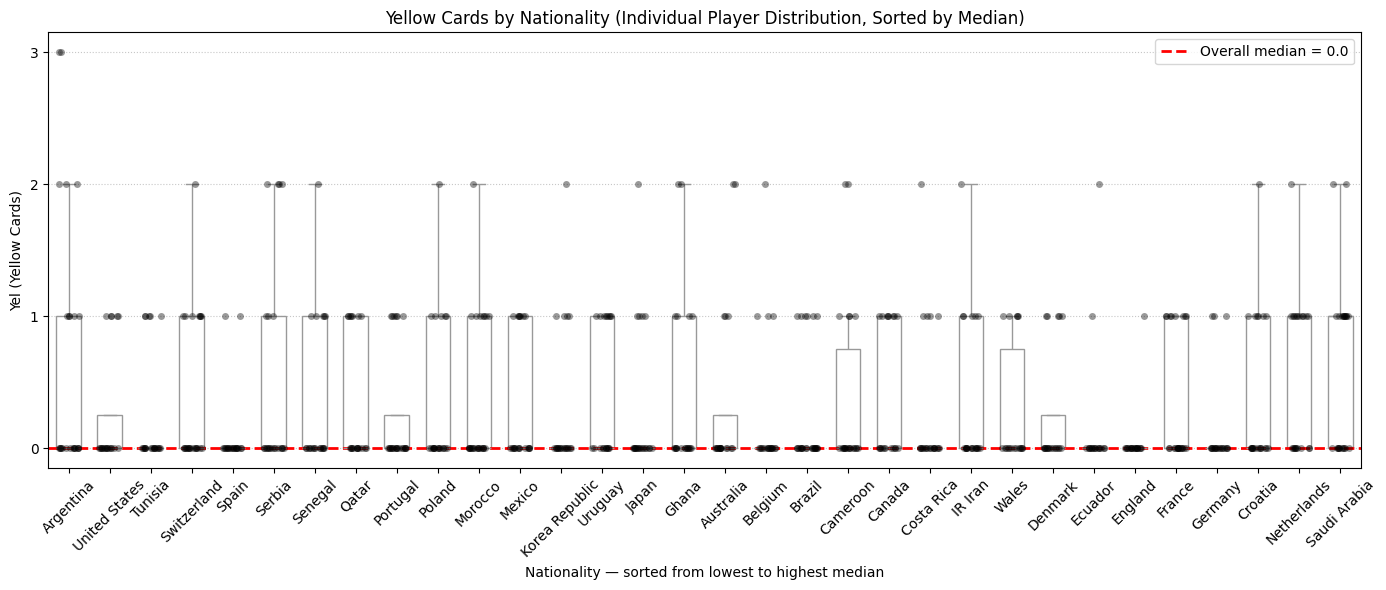

In [7]:
team_medians = df.groupby("nationality")["Yel"].median().sort_values()
teams_sorted = team_medians.index.tolist()
overall_median = df["Yel"].median()

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df,
    x="nationality",
    y="Yel",
    order=teams_sorted,
    color="white",
    showfliers=False,
    width=0.6
)

sns.stripplot(
    data=df,
    x="nationality",
    y="Yel",
    order=teams_sorted,
    jitter=0.25,
    size=5,
    color="black",
    alpha=0.4
)

plt.title("Yellow Cards by Nationality (Individual Player Distribution, Sorted by Median)")
plt.xlabel("Nationality — sorted from lowest to highest median")
plt.ylabel("Yel (Yellow Cards)")

plt.axhline(overall_median, linestyle="--", linewidth=2, color="red",
            label=f"Overall median = {overall_median}")

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle=":", alpha=0.7)
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(1))
plt.legend()
plt.tight_layout()
plt.show()

So, instead of only looking at team totals, this chart zooms in on **individual players** within each nationality. The **boxplot** summarizes the distribution of `cards_yellow` for each team, and the scattered dots show the actual player level values. I added a little **jitter** to the dots so they don’t stack perfectly on top of each other when you see a thick cluster at 0, it means most players on that team stayed out of trouble.

Because yellow cards are relatively rare, many teams end up with boxes that sit flat around **0 or 1**, which tells us a lot of players share the same “clean” record. The dots up at **2 or 3** are the outliers the few players who were much more aggressive than their teammates. The dashed red line at **0.0** is the big takeaway: it shows that the *typical* player in this dataset finished the tournament with **zero** yellow cards. Finally, I sorted the teams from left to right by their **median** yellow cards, so it’s easier to see the shift from the most disciplined teams to the ones where cards were more common.

### Q1(e) Create `Goals` and `Assists` as scatter. Signify your favorite club or nationality in some way on the scatterplot. You may need to add a new column to the dataset to do so.

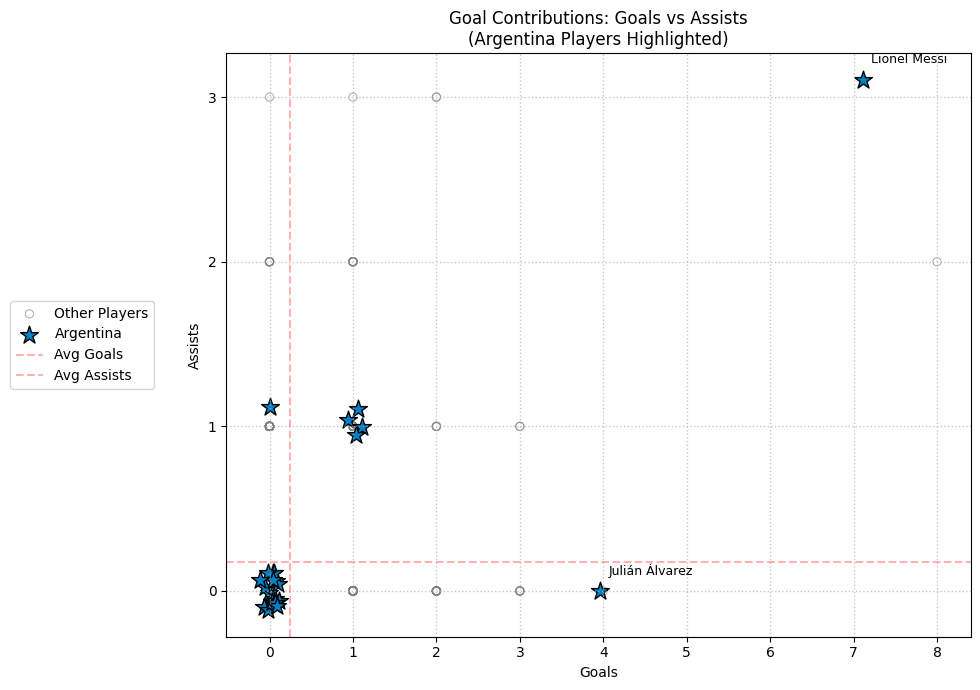

In [8]:
df["goals_num"] = pd.to_numeric(df["goals"], errors="coerce")
df["assists_num"] = pd.to_numeric(df["assists"], errors="coerce")

plot_df = df.dropna(subset=["goals_num", "assists_num"]).copy()

others = plot_df[plot_df["is_favorite"] == "Other"].copy()
fav = plot_df[plot_df["is_favorite"] == "Favorite"].copy()

fav["goals_j"] = fav["goals_num"] + np.random.uniform(-0.12, 0.12, len(fav))
fav["assists_j"] = fav["assists_num"] + np.random.uniform(-0.12, 0.12, len(fav))

plt.figure(figsize=(10, 7))

plt.scatter(
    others["goals_num"], others["assists_num"],
    s=35, facecolors="none", edgecolors="gray",
    linewidths=0.8, alpha=0.6,
    label="Other Players"
)

plt.scatter(
    fav["goals_j"], fav["assists_j"],
    s=180, marker="*", color="#0081C8",
    edgecolor="black", alpha=1.0,
    label="Argentina"
)

# Label standout Argentina players
for i, row in fav.iterrows():
    if row["goals_num"] > 1 or row["assists_num"] > 1:
        plt.text(row["goals_j"] + 0.1, row["assists_j"] + 0.1, row["player"], fontsize=9)

# Average benchmark lines
plt.axvline(plot_df["goals_num"].mean(), color="red", linestyle="--", alpha=0.3, label="Avg Goals")
plt.axhline(plot_df["assists_num"].mean(), color="red", linestyle="--", alpha=0.3, label="Avg Assists")

plt.title("Goal Contributions: Goals vs Assists\n(Argentina Players Highlighted)")
plt.xlabel("Goals")
plt.ylabel("Assists")

# Integer ticks + dotted grid lines
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.gca().yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.grid(True, which="major", linestyle=":", linewidth=1, alpha=0.7)

# Legend on the left
plt.legend(loc="center left", bbox_to_anchor=(-0.30, 0.5))

plt.tight_layout()
plt.show()

This scatterplot compares each player’s **Goals** (x-axis) to their **Assists** (y-axis), so every point represents one player’s total attacking contribution. Most players cluster near the bottom-left around (0,0), which tells us that the typical player finished with few or no goals and assists. I highlighted my favorite nationality, **Argentina**, using bigger star markers so those players stand out from the rest of the tournament (shown as hollow gray circles).

Because goals and assists are integers, many players share the exact same coordinates, so I added a small **jitter** only to the Argentina stars to prevent them from stacking directly on top of each other. The dashed red vertical and horizontal lines show the **overall average goals and assists**, which act like benchmarks players to the right of the vertical line scored above average goals, and players above the horizontal line provided above-average assists. The dotted grid makes it easier to read the integer values, and I labeled only the standout Argentina players (those with more than 1 goal or more than 1 assist) to keep the plot readable.

### Q1(f) Create a new visualization that I have not asked for. It can be anything but you should be creative

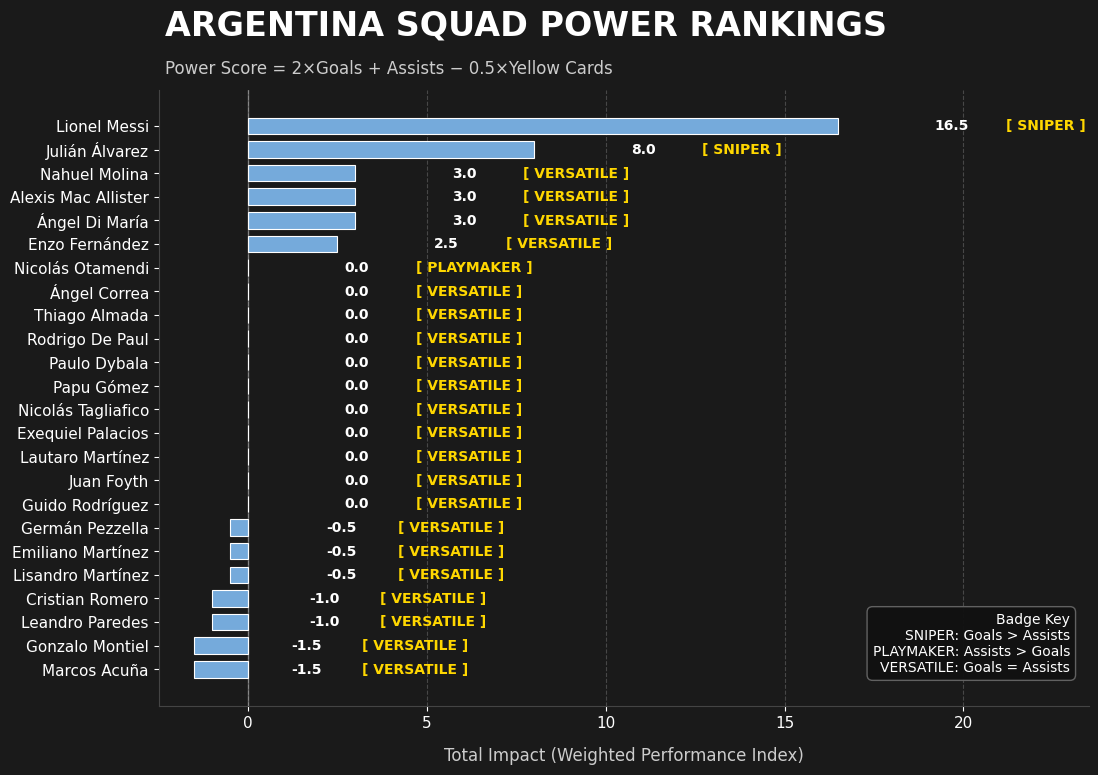

In [9]:
# Ensure Yel is numeric
plot_df["Yel_num"] = pd.to_numeric(plot_df["Yel"], errors="coerce")

# Power Score uses Yel_num now
plot_df["power_score"] = (plot_df["goals_num"] * 2) + plot_df["assists_num"] - (plot_df["Yel_num"] * 0.5)

arg_players = (
    plot_df[plot_df["is_favorite"] == "Favorite"]
    .dropna(subset=["player", "power_score", "goals_num", "assists_num", "Yel_num"])
    .sort_values("power_score", ascending=False)
)

bg_color = "#1A1A1A"
bar_color = "#75AADB"
accent_color = "#FFD700"
text_gray = "#CCCCCC"

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

fig.suptitle(
    "ARGENTINA SQUAD POWER RANKINGS",
    fontsize=24, color="white", fontweight="black",
    x=0.13, ha="left", y=0.98
)
fig.text(
    0.13, 0.90,
    "Power Score = 2×Goals + Assists − 0.5×Yellow Cards",
    fontsize=12, color=text_gray, ha="left"
)

bars = ax.barh(
    arg_players["player"],
    arg_players["power_score"],
    color=bar_color,
    edgecolor="white",
    linewidth=0.8,
    height=0.7
)
ax.invert_yaxis()

ax.axvline(0, color="white", linewidth=1, alpha=0.35)

max_abs = max(abs(arg_players["power_score"].min()), abs(arg_players["power_score"].max()))
pad = 0.04 * (max_abs + 1)

for i, bar in enumerate(bars):
    row = arg_players.iloc[i]

    if row["goals_num"] > row["assists_num"]:
        badge = "[ SNIPER ]"
    elif row["assists_num"] > row["goals_num"]:
        badge = "[ PLAYMAKER ]"
    else:
        badge = "[ VERSATILE ]"

    y = bar.get_y() + bar.get_height() / 2
    x = bar.get_width()

    ax.text(
        x + pad + 2, y,
        f"{row['power_score']:.1f}",
        va="center",
        color="white",
        fontsize=10,
        fontweight="bold"
    )

    ax.text(
        x + pad + 4, y,
        badge,
        va="center",
        color=accent_color,
        fontsize=10,
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#444444")
ax.spines["bottom"].set_color("#444444")
ax.tick_params(axis="both", colors="white", labelsize=11)

ax.xaxis.grid(True, linestyle="--", alpha=0.20, color="white")
ax.set_axisbelow(True)

ax.set_xlabel("Total Impact (Weighted Performance Index)", color=text_gray, fontsize=12, labelpad=12)
ax.set_xlim(arg_players["power_score"].min() - 1, arg_players["power_score"].max() + 7)

legend_text = (
    "Badge Key\n"
    "SNIPER: Goals > Assists\n"
    "PLAYMAKER: Assists > Goals\n"
    "VERSATILE: Goals = Assists"
)

ax.text(
    0.98, 0.05, legend_text,
    transform=ax.transAxes,
    fontsize=10,
    color="white",
    va="bottom",
    ha="right",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#111111", edgecolor="#666666", alpha=0.95)
)

plt.subplots_adjust(top=0.88)
plt.show()


For this creative visualization, I made my own Argentina Squad Power Rankings chart. I wanted something that feels more like an analyst dashboard instead of another basic plot.

First, I created a custom Power Score to summarize overall impact in one number: 2×Goals + Assists − 0.5×Yellow Cards. The idea is simple: goals matter the most, assists still add value, and yellow cards slightly reduce the score because they reflect discipline issues.

Then I filtered the dataset down to Argentina players only, sorted them from highest to lowest score, and plotted it as a horizontal bar chart so it’s easy to read player-by-player. I also added small badges next to each player to quickly describe their style: SNIPER (more goals than assists), PLAYMAKER (more assists than goals), or VERSATILE (balanced).

The result makes it obvious who stands out in terms of contribution, and it also shows that a lot of players have a score near zero which makes sense because many squad members may not score or assist, but they still contribute in ways that aren’t captured by these three stats.

### Q1(g) Visualize how certain you are about getting an A on this assignment. Try to be creative.

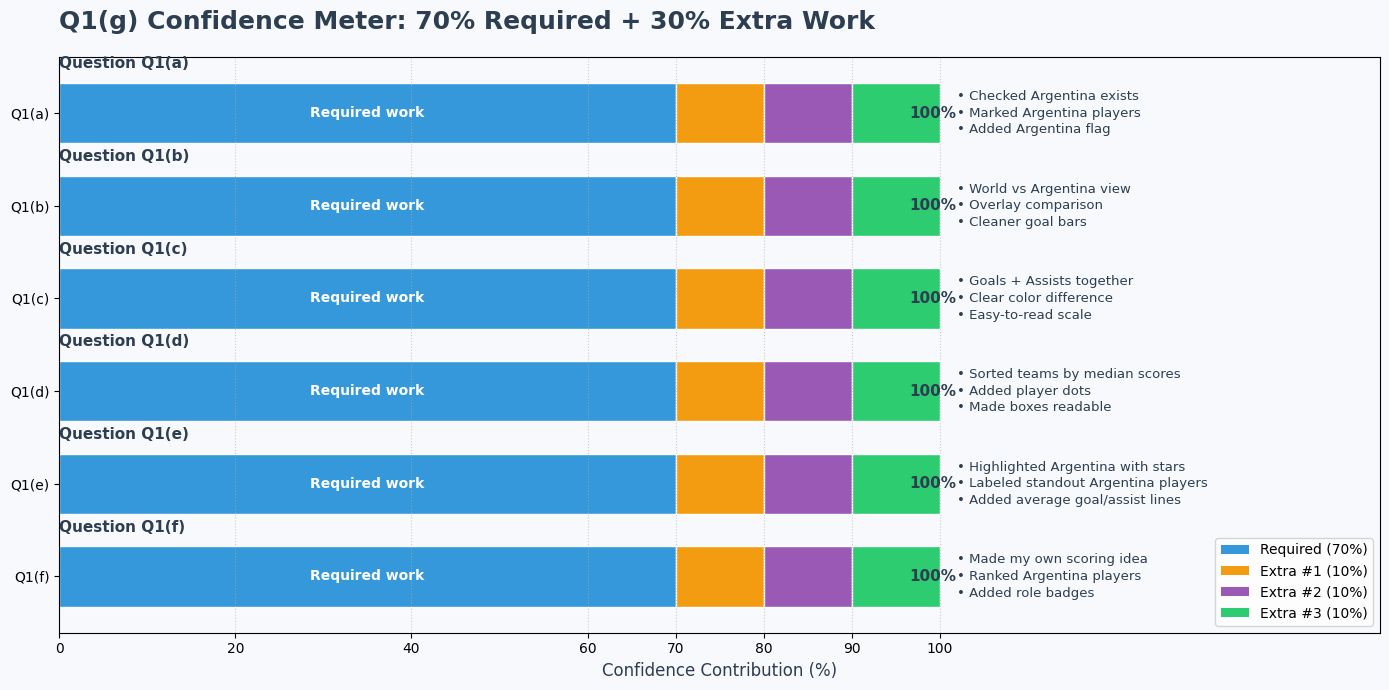

In [10]:
parts = ["Q1(a)", "Q1(b)", "Q1(c)", "Q1(d)", "Q1(e)", "Q1(f)"]
required = [70] * len(parts)

extras = {
    "Q1(a)": ["Checked Argentina exists", "Marked Argentina players", "Added Argentina flag"],
    "Q1(b)": ["World vs Argentina view", "Overlay comparison", "Cleaner goal bars"],
    "Q1(c)": ["Goals + Assists together", "Clear color difference", "Easy-to-read scale"],
    "Q1(d)": ["Sorted teams by median scores", "Added player dots", "Made boxes readable"],
    "Q1(e)": ["Highlighted Argentina with stars", "Labeled standout Argentina players", "Added average goal/assist lines"],
    "Q1(f)": ["Made my own scoring idea", "Ranked Argentina players", "Added role badges"]
}

bg_color = "#F7F9FC"
required_color = "#3498DB"
extra_colors = ["#F39C12", "#9B59B6", "#2ECC71"]
text_color = "#2C3E50"

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

y = np.arange(len(parts))

# Required
ax.barh(parts, required, color=required_color, edgecolor="white", height=0.65)

# Extra chunks (no text inside)
for i, part in enumerate(parts):
    left = 70
    for j in range(3):
        ax.barh(part, 10, left=left, color=extra_colors[j], edgecolor="white", height=0.65)
        left += 10

# Text inside the large 70% only
for i, part in enumerate(parts):
    ax.text(35, i, "Required work", va="center", ha="center",
            fontsize=10, fontweight="bold", color="white")

# Add "Question 1(a)" label ABOVE each bar
for i, part in enumerate(parts):
    ax.text(0, i - 0.45, f"Question {part}", va="bottom", ha="left",
            fontsize=11, fontweight="bold", color=text_color)

# Put extra descriptions OUTSIDE the bar (right side)
for i, part in enumerate(parts):
    x0 = 102
    e1, e2, e3 = extras[part]
    ax.text(x0, i - 0.18, f"• {e1}", va="center", ha="left", fontsize=9.5, color=text_color)
    ax.text(x0, i,        f"• {e2}", va="center", ha="left", fontsize=9.5, color=text_color)
    ax.text(x0, i + 0.18, f"• {e3}", va="center", ha="left", fontsize=9.5, color=text_color)

# Total % label
for i in range(len(parts)):
    ax.text(96.5, i, "100%", va="center", ha="left",
            fontsize=11, fontweight="black", color=text_color)

# Styling
ax.set_xlim(0, 150)
ax.invert_yaxis()
ax.set_xticks([0, 20, 40, 60, 70, 80, 90, 100])
ax.grid(axis="x", linestyle=":", alpha=0.6)

ax.set_title("Q1(g) Confidence Meter: 70% Required + 30% Extra Work",
             fontsize=18, fontweight="black", color=text_color, loc="left", pad=20)
ax.set_xlabel("Confidence Contribution (%)", color=text_color, fontsize=12)

legend_elements = [
    Patch(facecolor=required_color, label="Required (70%)"),
    Patch(facecolor=extra_colors[0], label="Extra #1 (10%)"),
    Patch(facecolor=extra_colors[1], label="Extra #2 (10%)"),
    Patch(facecolor=extra_colors[2], label="Extra #3 (10%)")
]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.show()

So for this one, I basically tried to show my confidence the same way I actually worked through the assignment.

Each bar is one part of Question 1 (a to f). I treated 70% of the bar as the required work like, the exact thing the question asked for. Then the last 30% is split into three smaller chunks, and those are the extra things I did on top of the requirements.

Like for some parts, I didn’t just make the plot and stop I also added things like a world vs Argentina comparison, overlay charts, sorting teams to make the boxplot readable, highlighting Argentina players on the scatter, and then the creative ranking idea for part (f).I kept the extra explanations on the right side because putting text inside the tiny 10% pieces looked messy, and this way it’s way easier to read.

So yeah the reason everything shows 100% is because I’m not just done. I actually did the required stuff plus improvements for every section, which is why I feel fully confident about getting an A.

## Question 2 (Examine the following image for graphical excellence) :

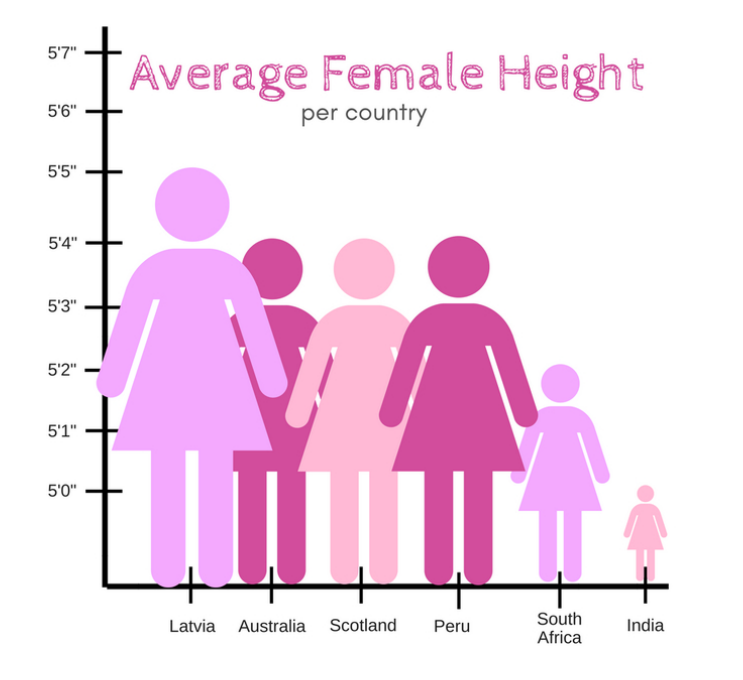

In [11]:
display(Image(filename="images/Q2.png", width=600, height=300))

This image is basically a how to accidentally (or intentionally) mislead people with data example. It looks like it’s comparing average heights of women across countries, but the design choices make the differences look way bigger than they really are.

### 1) What story is the chart trying to tell?
The chart claims to show **average female height** by country. However, because of the way it’s drawn, it ends up feeling like women in Latvia are huge giants and women in India are unbelievably small. In reality, the actual difference is only a few inches, so the visual impression is far more dramatic than the real data.

### 2) What goes wrong (the graphical sins)
- **Truncated y-axis:** The scale starts around **5'0"** instead of **0**, which zooms in on only the top part of the heights and makes small differences look huge.
- **Icons scale by area, not just height:** The full-body figures get both taller and wider, so the eye compares overall size, which exaggerates the difference even more.
- **Artwork doesn’t match the numbers cleanly:** Some icons don’t line up perfectly with the tick marks (for example, an average listed at **5'0"** should clearly hit that line), which makes the graphic feel less trustworthy.

### 3) How I would fix it
To make this graphical excellence, I’d start the y-axis at **0** so the proportions stay honest and the differences aren’t artificially magnified. I’d also replace the icons with a simple **bar chart** or **dot plot**, because those are much easier to read and harder to misinterpret. If we wanted to stay creative, I’d rather show a cluster of dots representing individual heights (or simulated points) so we can see the **range**, not just a single average. Sorting countries from tallest to shortest is actually helpful, and they mostly did that already it’s the distortion from the axis and icon scaling that ruins the chart.

### Big takeaway
Even when the numbers might be correct, the design can still mislead the viewer. This graphic makes small height differences look massive mainly because of the **cut y-axis** and the way the human icons are scaled, which exaggerates the comparison.

## Question 3  (Questions about the exam):

### (a) Approximately how long did you work on this exam?
I’d say I worked on this exam for about **4–5 hours** overall. A lot of that time wasn’t just writing code, but making sure the plots actually looked clean and followed the instructions (titles, labels, readable bins, and the extra comparisons).

### (b) Which was the hardest and easiest topic from this section?
The hardest part for me was the **boxplot by nationality**, not because drawing it is complicated, but because interpreting it gets tricky when so many players have **zero** yellow cards so the medians flatten out and the outliers become the main thing you notice. The easiest part was the **histograms** (Goals and Goals vs Assists), since once the bins were set up as whole numbers and everything was labeled properly, the distribution patterns were pretty straightforward to understand.

### (c) Which method of visualization are you still unclear what it might show?
I’m still a bit unclear about **radar/spider charts**. They look impressive, but I don’t always feel confident about what they truly communicate, because it’s harder to compare values accurately than with something simpler like a bar chart or dot plot.

## Question 4 (Documentation of Resources):

Below are the prompts I used with an LLM while working on the coding/visualization parts of the exam (Question 1). I did not use an LLM to generate my written critique for the graphics question.

1. **Q1(a) Favorite nationality + image** 


   Prompt: Write a single-cell code block to select my favorite nationality (Argentina) from the dataset, verify it exists, create a highlight column, and display the Argentina flag image at 200×200.

3. **Q1(b) Goals histogram**


   Prompt: Create a goals histogram with integer-aligned bins, title/labels/grid, and show it for world players, Argentina players, and an overlay comparison.

4. **Q1(c) Goals & assists histogram on same axis**


   Prompt: Create a histogram of Goals and Assists on the same axis (world + Argentina) with clear colors, integer ticks, and dotted gridlines.

5. **Q1(d) Yellow cards boxplot**  


   Prompt: Create a boxplot of yellow cards by nationality and then improve it (sorted by median + add jittered points/stripplot for readability).

6. **Q1(e) Scatterplot goals vs assists**


   Prompt: Make a Goals vs Assists scatterplot and highlight Argentina clearly. Use jitter to avoid overlap, add average benchmark lines, integer ticks, gridlines, and label only standout Argentina players.

7. **Q1(f) Creative visualization (how I got there)**


   Prompt 1: I need something different and creative for part (f). What are a few good plot ideas using this World Cup dataset that go beyond histograms/boxplots/scatterplots?  
   Prompt 2: Can we do something that ranks Argentina players in an interesting way instead of another basic chart?  
   Prompt 3: Let’s build a “Power Score” so it feels like a real-world performance metric. Can you suggest a simple formula using goals, assists, and yellow cards?  
   Prompt 4: Now plot Argentina players as a horizontal ranking chart and make it look premium (dark theme, readable labels).  
   Prompt 5: Add simple role tags to explain each player’s style (for example: Sniper if goals > assists, Playmaker if assists > goals, Versatile if equal).  
   Prompt 6: Fix text overlap and add a small legend box that explains what each badge means.

8. **Q1(g) Confidence visualization (how I got there)**


   Prompt 1: For part (g) I want to say I’m 100% confident. How can I visualize that in a creative way instead of just writing “100%”?  
   Prompt 2: Make it reflect the work I actually did for Q1(b)–Q1(f), not just a generic confidence bar.  
   Prompt 3: I want each part to show 70% for required work and 30% for extra improvements I added. Can you design that chart?  
   Prompt 4: The text inside the small sections is messy. How can we restructure the plot so it stays clean and readable?  
   Prompt 5: Put the extra explanations outside the bars and label each row clearly as Question 1(a), 1(b), etc. 

### (b) Detail responses and show what was accepted or rejected
Accepted: I kept integer-aligned bins for histograms so bars matched whole-number goal counts. I included world vs Argentina views and overlays because they clearly show comparisons. I improved the yellow card boxplot by sorting and adding player dots because a plain boxplot was hard to interpret with many zeros. For the scatterplot, I highlighted Argentina, used jitter, added average benchmark lines, and labeled only standout players to keep it readable. I also accepted the creative Power Score ranking because it adds an original way to summarize performance.

Rejected/Changed: I did not keep long text labels inside tiny 10% bar segments in the confidence chart because it became cluttered, so I moved the descriptions outside the bars. When overlays made a plot too busy, I simplified the visualization to keep it clear.

### (c) Outside resources (non-LLM)
Dataset (course link): https://raw.githubusercontent.com/nurfnick/Data-Sets-For-Stats/refs/heads/master/CuratedDataSets/2022WorldCup.csv  
Python references used: pandas documentation, matplotlib documentation, seaborn documentation.

### (d) Required statement
**I attest that the resources above were the only ones utilized in completing the exam and the work included is my own and no one else from the course.**